# **Homework assignment**


> Oskar Krawczyk, AIML22 Group 3





---


As part of this homework assignment, we will go through topics covered in the past few days, specifically computer vision for object detection using single-stage detectors from YOLO (You Only Look Once) family. To do so, we will create a custom dataset based on the [DOTA OBB dataset](https://docs.ultralytics.com/tasks/obb#visual-samples$0). Then, we will consider multiple YOLO model variants, train them and eventually compare their results using various object detection metrics, including mAP, precision and recall.

In the following notebook, I split my solution into four separate sections - Part 1, 2, 3, 4 - which follow the convention used in the initial *Oriented_YOLO_Homework_Assignment.ipynb* notebook. Each section includes the code as part of my solution as well as a brief explanation of certain concepts not mentioned during lectures/seminars. At the end of this notebook, I also denote resources used to complete and/or improve the final results.


---




## Part 1

In this section we first import all necessary libraries into a single cell. The reason is that in the future if someone tries to access the very same code, it is preferable to keep it in the single cell instead of imports scattered across the entire notebook. Then, we set up the notebook by specifying settings for plotting (matplotlib/seaborn), device and verify versions of libraries imported. Finally, we download the dataset, parse it and display its description (number of samples, classes, paths, ...).

In [2]:
# !rm -rf /content/DOTA-Demo-1 # Run if Roboflow connections has been lost/interrupted

The following cell is optional, nonetheless it is highly recommended (especially while running on Google Colab) since libraries like roboflow are not included in the standard setup. While debugging, removing -qq might be potentially handy since this flag displays critical erros only.

In [3]:
!pip install -qq ultralytics roboflow matplotlib pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 117.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.8 MB/s eta 0:00:00


#### Library imports

In [4]:
import os
import pathlib
import yaml
import colorsys
import random
import time
import cv2

import pandas as pd
import numpy as np
import ultralytics

import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import seaborn as sns
import math

import torch
from torch.utils.data import Dataset

from roboflow import Roboflow
from ultralytics import YOLO
from typing import List

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


#### Notebook setup

Here, we set (by preference) matplotlib and seaborn default settings partly due to consistent plotting. We then display information regarding imported libraries - if at some point in the future any methods are changed in those libraries, this is a place to go.

In [5]:
plt.rcParams["figure.figsize"] = (12, 12)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.grid"] = False
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["figure.edgecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "lightgray"
plt.rcParams["figure.dpi"] = 100

sns.set_theme(style = "whitegrid", palette = "muted")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("--- Notebook setup info ---")
print(f"Device:        {device}")
print(f"PyTorch:       {torch.__version__}")
print(f"OpenCV:        {cv2.__version__}")
print(f"Ultralytics:   {ultralytics.__version__}")
print(f"Numpy:         {np.__version__}")

--- Notebook setup info ---
Device:        cuda
PyTorch:       2.11.0+cu128
OpenCV:        4.10.0
Ultralytics:   8.4.104
Numpy:         2.0.2


#### Introduce the dataset

Here, we first initialise the Roboflow API using a personal key and download the DOTA-demo dataset in the YOLOv8-OBB format (as suggested). Then we locate and parse the downloaded *data.yaml* configuration file. The reason why we modify and overwrite the path variable inside this file is that Roboflow often exports a default virtual path, which must be updated to our local path to ensure YOLO can correctly locate the images during training. Finally, we print out a detailed summary of the dataset's configuration, displaying the verified paths, the numnber of classes and the full list of class names.

**Note**: It is required to use YAML in this notebook. [YAML](https://yaml.org/$0) - "YAML Ain't Markup Language" is a human-friendly data serialisation language.



In [6]:
PERSONAL_KEY = "rkdxr9QmPL4JSdG1T0KX"
roboflow = Roboflow(api_key = PERSONAL_KEY)

chosen_dataset = "dota-demo"
project = roboflow.workspace("rotated-object-detection").project(chosen_dataset)
dataset = project.version(1).download("yolov8-obb")

dataset_path = pathlib.Path(dataset.location)
yaml_path = dataset_path / "data.yaml"

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to DOTA-Demo-1 in yolov8-obb:: 100%|██████████| 128/128 [00:00<00:00, 2132.30it/s]


In [7]:
with open(yaml_path, "r") as file:
    data_config = yaml.safe_load(file)

data_config["path"] = str(dataset_path.resolve())
with open(yaml_path, "w") as file:
    yaml.safe_dump(data_config, file)

print("Dataset - DOTA OBB - has been configured successfully.\n")

print("--- Dataset information ---")
print(f"Root path:                {data_config["path"]}")
print(f"Train dataset path:       {data_config["train"]}")
print(f"Validation dataset path:  {data_config["val"]}")
print(f"Test dataset path:        {data_config["test"]}")
print(f"Number of classes:        {len(data_config["names"])}")

print()

print("Classes in the dataset")
for i in range(len(data_config["names"])):
    print(f"{i}: {data_config['names'][i]}")

Dataset - DOTA OBB - has been configured successfully.

--- Dataset information ---
Root path:                /content/DOTA-Demo-1
Train dataset path:       train/images
Validation dataset path:  valid/images
Test dataset path:        test/images
Number of classes:        5

Classes in the dataset
0: harbor
1: large-vehicle
2: plane
3: ship
4: small-vehicle


## Part 2

In this section, we define the DOTAOBBDataset, a custom dataset class to handle Oriented Bounding Box data imported in Part 1. The class is equipped with multiple methods to properly process the dataset. The goal is to define the core methods needed to pair images with their corresponding labels, convert YOLO's normalised coordinates into drawable pixel coordinates and create a visualisation tool for the rotated boxes. Finally, we instantiate the datasets for the train / validation / test splits and summarise their structures.

#### Create Dataset

**Note**: in this YOLO dataset, bounding box coordinates are saved as normalised values (% between 0 and 1). Therefore to figure out where the pixel actually is, we have to multiply the percentage by the actual width of the image (the same applies to its heights and y position). The coordinates on the other hand are stored in the [x1, y1, x2, y2, x3, y3, x4, y4] manner.

In [8]:
class DOTAOBBDataset(Dataset):
    '''
    Custom dataset class for handling Oriented Bounding Box data, speficially designed
    for YOLO-OBB formats and DOTA datasets.
    '''

    def __init__(self, images_dir: str, labels_dir: str, class_names: List[str], transform = None):
        super().__init__()
        self.images_dir = pathlib.Path(images_dir)
        self.labels_dir = pathlib.Path(labels_dir)

        self.class_names = class_names
        self.transform = transform
        self.num_classes = len(class_names)

        image_files = []
        for root, dirs, files in os.walk(images_dir):
            for file in files:
                if file.endswith(".jpg") or file.endswith(".png"):
                    image_files.append(os.path.join(root, file))

        image_files = sorted(image_files)

        self.samples = []
        for image_path in image_files:
            temp_path = self.labels_dir / f"{pathlib.Path(image_path).stem}.txt"
            self.samples.append((image_path, temp_path))


    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index: int):
        image_path, label_path = self.samples[index]

        extracted_image = cv2.imread(image_path)
        image = cv2.cvtColor(extracted_image, cv2.COLOR_BGR2RGB)

        image_height, image_width = image.shape[0], image.shape[1]

        annotations = self.load_obb_annotations(label_path, image_width, image_height)

        if self.transform:
            image = self.transform(image = image)

        return {"image": image, "annotations": annotations, "image_path": image_path, "image_size": (image_height, image_width)}

    def __str__(self):
        dataset_name = self.images_dir.parent.name

        statistics = (
            "----------------------------------------------\n"
            "\n"
            f"Dataset: {dataset_name}\n"
            f"Number of classes: {self.num_classes}\n"
            f"Number of images: {len(self.samples)}\n"
            f"Classes: {', '.join(self.class_names)}\n"
            "\n"
            "----------------------------------------------"
        )

        return statistics


    def load_obb_annotations(self, label_path: pathlib.Path, img_w: int, img_h: int):
        '''
        Reads YOLO OBB formatted text files and scales normalised coordinates to pixel coordinates.

        Args:
            label_path: Path to the label file.
            img_w: Width of the image.
            img_h: Height of the image.

        Returns:
            annotations: a list of dictionaries, where each dictionary contains details
            for a single bounding box (class_id, class_name, coordinates, normalised coordinates, pixel coordinates)
        '''

        with open(label_path, "r") as file:
            lines = file.readlines()

        annotations = []
        for line in lines:
            line = line.strip()

            if not line:
                continue

            parts = line.split()
            class_id = int(parts[0])
            coordinates = [float(x) for x in parts[1:9]]

            normalised_coordinates = []
            for i in range(4):
                x = coordinates[2 * i] * img_w
                y = coordinates[2 * i + 1] * img_h
                normalised_coordinates.append([x, y])

            annotations.append({
                "class_id": class_id,
                "class_name": self.class_names[class_id],
                "obb_coords": coordinates,
                "pixel_coords": normalised_coordinates
            })

        return annotations

    def visualise_sample(self, index: int, figsize: tuple = (12, 8)):
        '''
        Plots an image from the dataset and overlays its oriented bounding boxes.

        Args:
            index: Index of the sample to be plotted.
            figsize: Size of the figure.
        '''

        sample_data = self.__getitem__(index)

        if torch.is_tensor(sample_data["image"]):
            image = sample_data["image"].numpy().transpose((1, 2, 0))
        else:
            image = sample_data["image"]

        fig, ax = plt.subplots(figsize = figsize)
        fig.suptitle("Sample image")
        ax.imshow(image)

        for annotation in sample_data["annotations"]:
            class_idx = annotation["class_id"]
            class_name = annotation["class_name"]
            obb_coords = annotation["obb_coords"]
            pixel_coords = annotation["pixel_coords"]

            extracted_coordinates = np.array([pixel_coords]).reshape(4, 2)
            closed_polygon = np.vstack([extracted_coordinates, extracted_coordinates[0]])

            colour = self.get_class_colour(class_idx)

            ax.plot(closed_polygon[:, 0], closed_polygon[:, 1], color = colour, linewidth = 1)
            ax.fill(closed_polygon[:, 0], closed_polygon[:, 1], color = colour, alpha = 0.3)
            ax.text(pixel_coords[0][0], pixel_coords[0][1], class_name, color = "white", fontsize = 10,
                    bbox = dict(facecolor = colour, edgecolor = "none", alpha = .8, pad = 2.0),
                    path_effects = [path_effects.withStroke(linewidth = .4, foreground = "white")])


        plt.title(f"{index}: {pathlib.Path(sample_data["image_path"]).name}")
        plt.axis(False)
        plt.tight_layout()
        plt.show()


    def get_class_colour(self, class_idx: int):
        '''
        Generates a distinct colour for a given class index using the golden ratio
        in the HSV colour space to ensure visual separation between classes.
        See documentation for more.

        Args:
            class_idx: Index of the class.

        Returns:
            A tuple representing the colour in RGB format.
        '''

        if not hasattr(self, "_color_cache"):
            self._color_cache = {}

        if class_idx in self._color_cache:
            return self._color_cache[class_idx]

        golden_ratio = (1 + math.sqrt(5)) / 2.0
        hue = (class_idx * golden_ratio) % 1.0
        saturation = 1.0
        value = 1.0

        red, green, blue = colorsys.hsv_to_rgb(hue, saturation, value)
        out_colour = (red, green, blue, 1.0)

        self._color_cache[class_idx] = out_colour

        return out_colour


#### Split into train/test/valid datasets

We now need to retrieve the list of all classes (their names) to pass it as an argument to create an instance of our dataset. We then create train, test and validation datasets to later show their descriptions - e.g. number of samples.

In [9]:
class_names = list(data_config["names"].values())

train_dataset = DOTAOBBDataset(dataset_path / "train" / "images", dataset_path / "train" / "labels", class_names)
test_dataset = DOTAOBBDataset(dataset_path / "test" / "images", dataset_path / "test" / "labels", class_names)
valid_dataset = DOTAOBBDataset(dataset_path / "valid" / "images", dataset_path / "valid" / "labels", class_names)

In [19]:
print("Datasets descriptions\n")

print(train_dataset)
print(test_dataset)
print(valid_dataset)

Datasets descriptions

----------------------------------------------

Dataset: train
Number of classes: 5
Number of images: 40
Classes: harbor, large-vehicle, plane, ship, small-vehicle

----------------------------------------------
----------------------------------------------

Dataset: test
Number of classes: 5
Number of images: 6
Classes: harbor, large-vehicle, plane, ship, small-vehicle

----------------------------------------------
----------------------------------------------

Dataset: valid
Number of classes: 5
Number of images: 12
Classes: harbor, large-vehicle, plane, ship, small-vehicle

----------------------------------------------


#### Investigate the results

In here, we display three randomly sampled images and their corresponding labels, that is classified bounded objects. We use a large scale (figsize = (8, 8)) on purpose to see the bounding boxes of even small objects well.

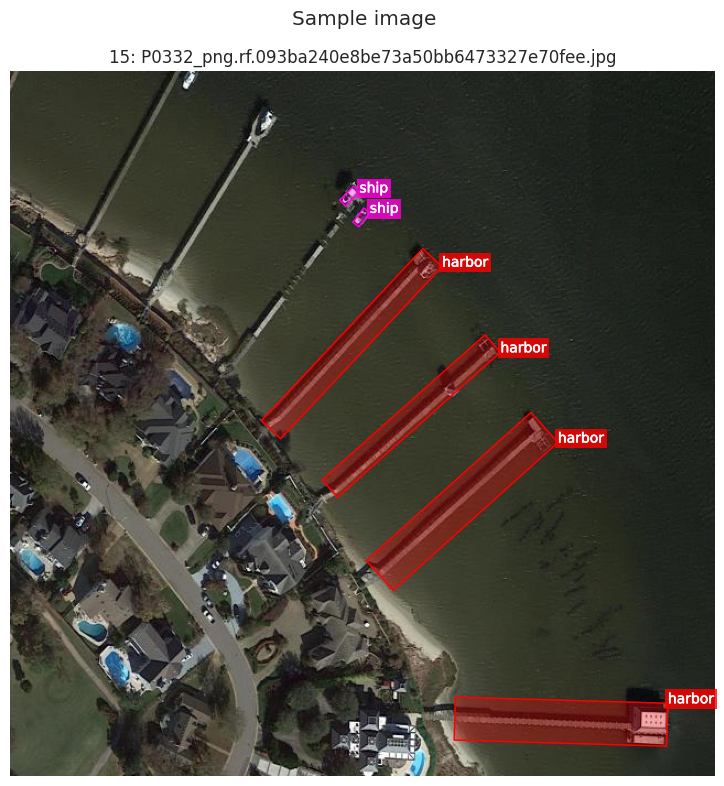

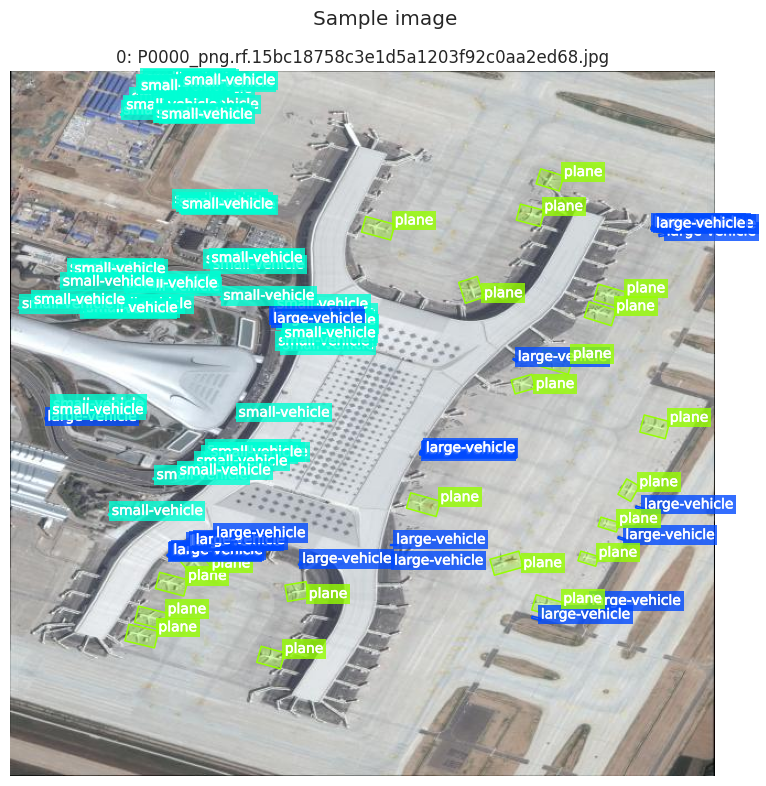

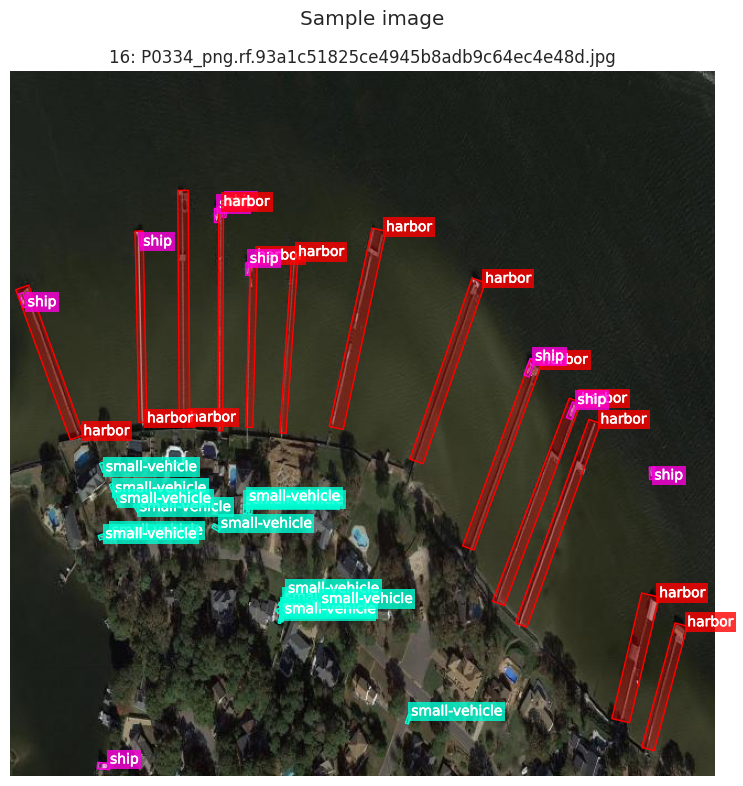

In [11]:
random_samples = [random.randint(0, 39) for _ in range(3)]

for i in random_samples:
    train_dataset.visualise_sample(i, figsize = (8, 8))

## Part 3

In this section we perform models' training on the dataset implemented in Part 2. In particular, we select three various YOLO models:

*   YOLO11n
*   YOLOv8n
*   YOLOv8m

Each of these models is characterised by its parameters. Specifically, according to the official documentation, YOLO11n and YOLOv8n belong to so-called nano YOLO family (~3 million parameters). On the other hand, YOLOv8m belongs to so-called medium YOLO family (\~26 million parameters) and the model itself shares the same foundational architecture as YOLOv8n, yet scales the network significantly deeper. Since it is rather beyond this notebook's scope and the information above should be enough, YOLO11n's efficiency is mostly based on the use of [attention mechanism](https://arxiv.org/html/2410.17725v1$0) while YOLOv8 is characterised by anchor-free split detection head, meaning that it predicts the centre of an object directly rather than relying on predefined anchor boxes as it was the case in the initial YOLO variant models.

Finally, we set main hyperparameters (see below) and based on that we perform training of each model while keeping track of various metrics (mainly mAP). At the end we compare training time of each model.

#### Training configuration

We first create a directory for the results obtained throughout training. Then we set hyperparameters and set config of the models which will be trained.

In [12]:
results_dir = pathlib.Path("./trained_models")
results_dir.mkdir(exist_ok = True)

EPOCHS = 30
BATCH_SIZE = 8
IMAGE_SIZE = 1024

models_config = {
    "yolo11n-obb": {
        "model_name": "yolo11n-obb.pt",
        "description": "YOLO11n",
        "save_dir": results_dir / "yolo11n-obb"
    },
    "yolov8n-obb": {
        "model_name": "yolov8n-obb.pt",
        "description": "YOLO8n",
        "save_dir": results_dir / "yolo8n-obb"
    },
    "yolov8m-obb": {
        "model_name": "yolov8m-obb.pt",
        "description": "YOLO8m",
        "save_dir": results_dir / "yolo8m-obb"
    }
}

#### Training and outcomes

We perform the training loop for each model. To do so, we use the config saved in the cell above. We measure the time of each model's training and then we save the results. Then, we perform initial comparison of each model's result (we will develop it further in Part 4).

In [13]:
training_results = {}

for model_key, config in models_config.items():
    model = YOLO(config["model_name"])

    start_time = time.time()

    results = model.train(
        data = str(yaml_path),
        epochs = EPOCHS,
        imgsz = IMAGE_SIZE,
        batch = BATCH_SIZE,
        project = str(results_dir),
        name = model_key,
        exist_ok = True,
        verbose = False,
    )

    end_time = time.time()
    sum_time = end_time - start_time

    training_results[model_key] = {
        "training_time": sum_time,
        "results": results,
        "weights_path": results_dir / model_key / "weights" / "best.pt"
    }

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/DOTA-Demo-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n-obb, nbs=64, nms=False, opset=None, optim

I have performed multiple training cycles over the dataset with various parameters, especially varying number of epochs, image resolutions and transformations of training samples. After careful examination, it turned out that the best results have been achieved by the model with parameters above.

Specficially, with the same models and comparable training time, I managed to achieve the results of at least 0.40 mAP on each model, with 0.50 mAP on YOLOv8m.



The above-mentioned results are not entirely surprising. Once again, it should be noted that we are working with a very small dataset - 40 training samples and only 12 validation samples. It is therefore no wonder that the results are not in the range of 0.70+ mAP, since training on such a small dataset and with low-parameter models like those from the nano YOLO family prevents us from achieving such high scores. The changes I made to obtain these results stemmed primarily from intuitive reasoning and experimentations. Note that if we were to work with images at a size of 640, we would significantly compress the resolution of our images. In this scenario, when dealing with models based on satellite images, even the human eye might struggle to spot cars from a bird's-eye view in low-resolution images. Hence, increasing the resolution to 1024 while decreasing number of epochs, significantly improved the obtained results presented above.

In [18]:
print("Finished training - Models trained successfully.\n")

for model_key, res in training_results.items():
    print(f"{model_key}: {round(res['training_time']/60.0, 2)} minutes")

Finished training - Models trained successfully.

yolo11n-obb: 2.65 minutes
yolov8n-obb: 1.84 minutes
yolov8m-obb: 5.38 minutes


As it has already been mentioned in the brief explanation of each model, it is expected that the training time of nano models will be significantly lower than the medium ones. When it comes to nano models, the differences between the training time might have been caused by multiple factors, including the use of spatial attention mechanism in YOLO11n while YOLO8 standard conv blocks, or the fact that in detail, YOLOv8N has roughly 3.2 million parameters while YOLO11n about 2.6 million parameters.

## Part 4

In this section, we move to the very last part of the solution - evaluation and visualisation. We will first load all the trained models and in the upcoming parts we will be able to see the results achieved by each model on our custom dataset. I decided to omit the radar plot since I believe that it does not add much to the final evaluation and it might add additional "noise" to this stage while it can be easily replaces by more user-friendly methods I used below.

#### Load trained models above

First, we need to load the models we actually used throughout training so that we can evaluate their performance.

In [ ]:
trained_models = {}
for model_key, result in training_results.items():
    temp_path = pathlib.Path("runs/obb/trained_models") / model_key / "weights" / "best.pt"
    trained_models[model_key] = YOLO(temp_path)

#### Evaluation

We go through all models and calculate finals results, that is metrics for the corresponding model.

In [15]:
evaluation_results = {}
map_results = {}

EPSILON = 1e-10

for model_key, model in trained_models.items():
    start_time = time.time()

    metrics = model.val(data = str(yaml_path), split = "val", verbose = False)

    end_time = time.time()
    total_time = end_time - start_time

    precision = metrics.box.mp
    recall = metrics.box.mr
    f1_score = 2 * (precision * recall) / (precision + recall + EPSILON)

    map50 = metrics.box.map50
    map50_95 = metrics.box.map

    evaluation_results[model_key] = {
        "time": total_time,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,
        "map50": map50,
        "map50_95": map50_95
    }

    classes = metrics.box.ap_class_index
    ap_50_class = metrics.box.ap50

    class_ap = {}
    for (index, ap) in zip(classes, ap_50_class):
        name = class_names[index]
        class_ap[name] = ap

    evaluation_results[model_key]["class_ap"] = class_ap
    map_results[model_key] = class_ap # solely to heatmap

FileNotFoundError: [Errno 2] No such file or directory: 'trained_models/yolo11n-obb/weights/best.pt'

#### Metrics summary

Now, we shall display in the form of a table all statistics achieved for each model.

In [ ]:
summary_data = {
    model: {k: v for k, v in metrics.items() if k != "class_ap"}
    for model, metrics in evaluation_results.items()
}

summary_df = pd.DataFrame(summary_data).T
display(summary_df.round(3))

#### Model comparison - bar chart

In [ ]:
metrics_used = ["map50", "map50_95", "precision", "recall", "f1_score", "time"]
fig, axes = plt.subplots(3, 2, figsize = (10, 10))
fig.suptitle("Model performance comparison")

axes = axes.flatten()
colours_list = ["#FF9999", "#66B2FF", "#99FF99"]

for idx, metric in enumerate(metrics_used):
    ax = axes[idx]
    values = summary_df[metric]
    models = summary_df.index

    bars = ax.bar(models, values, color = colours_list[:len(models)])
    ax.set_title(metric)

    for bar in bars:
        y = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, y, f"{y:.2f}", ha = "center", va = "bottom")

plt.tight_layout()
plt.show()

#### Model comparison - heatmap

In [ ]:
heatmap_data = pd.DataFrame(map_results)

sns.heatmap(heatmap_data, annot = True)
plt.xlabel("Models")
plt.ylabel("Classes")
plt.show()

#### Plot predictions comparison

In [ ]:
def plot_prediction_comparison(models, image_paths):
    '''
    Plotting predicted OBB for given sample images.

    Args:
        models: dictionary containing trained OBB models.
        image_paths: image paths to selected images.
    '''

    num_images = len(image_paths)
    num_models = len(models)

    fig, axes = plt.subplots(num_images, num_models)

    for i, image_path in enumerate(image_paths):
        for j, (model_name, model) in enumerate(models.items()):
            ax = axes[i, j]

            results = model.predict(source = str(image_path), imgsz = 640, conf = 0.25)
            annotated_image = results[0].plot()
            annotated_image = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

            ax.imshow(annotated_image)
            ax.set_title(model_name)
            ax.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
sample_images = dataset_path / "test" / "images"
all_images = list(map(str, list(sample_images.glob("*"))))

samples = random.sample(all_images, 3)

plot_prediction_comparison(trained_models, samples)

## Summary

We have gone through the whole pipeline of computer vision object detection - from downloading the dataset, through creating a custom dataset class, all the way to training and evaluation. The last question to answer is: "Which model is the best and why?" and the best answer would probably be: "depends.". Whether it is model parameters, training time, number of samples and metrics we do care about, the answer might vary. If we were to focus solely on the dataset above, without any changes to the dataset being made, the best performace has been achieved by the model from the medium family, which as it has already been described is not surprising given for example the number of parameters. I believe, in my solution I have gone through all requirements given in the initial notebook and I am always open to any questions whether it is to add/remove something or clarify my code.

## References




Throughout the notebook (and while studying) I have used the following resources:


*   YOLO original paper: https://arxiv.org/pdf/1506.02640$0
*   Roboflow dataset documentation: https://docs.roboflow.com/datasets/adding-data#python-sdk$0


*   Python documentation: https://docs.python.org/3.6/library/typing.html$0
*   Class colours method: https://medium.com/@yamini1020.yanamala/the-art-and-science-of-color-creating-stunning-ui-palettes-6aea0a1c13b1$0

* Golden ratio in colours: https://medium.com/@winwardo/simple-non-repeating-colour-generation-6efc995832b8$0

---





logo_lg.svg